<a href="https://colab.research.google.com/github/Bebarzzz/machine-/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# The models
from sklearn.ensemble import RandomForestClassifier

In [16]:
df = pd.read_csv('Chronotype_NHANES_Imputation1.csv')
df.head()



,Seqn,Gender,Age,Race,BMI,Waist_C,Systolic,Diastolic,Carb_diet,HSCRP,Smokingstatus,Alcohol,Sleep_hrs,Sleeptime,Wakeuptime,Chronotype_slphrs,WakeUpCat
0,83732,1,62,2.0,27.8,101.1,122.6667,65.33334,126.0,0.6,3.0,1.0,5.5,23:30:00,05:00:00,3.0,1
1,83733,1,53,2.0,30.8,107.9,140.0000,86.00000,126.0,1.4,1.0,7.0,8.0,23:00:00,07:00:00,3.0,3
2,83734,1,78,2.0,28.8,116.5,135.3333,45.33333,96.0,0.6,3.0,0.0,7.0,22:30:00,05:30:00,2.0,2
3,83735,2,56,2.0,42.4,110.1,134.0000,70.00000,216.0,9.0,3.0,3.0,6.5,23:30:00,06:00:00,3.0,2
4,83741,1,22,3.0,28.0,86.6,111.3333,72.66666,5.5,1.3,2.0,3.0,6.5,23:00:00,05:30:00,3.0,2


### Data Preparation
We need to separate the target variable `Chronotype_slphrs` from the features. We should also remove identifiers like `Seqn` and non-numeric time columns that aren't ready for modeling.

In [33]:
# 1. Apply Winsorization (Clipping) to handle outliers
def handle_outliers(df_in, columns):
    df_out = df_in.copy()
    for col in columns:
        lower = df_out[col].quantile(0.01)
        upper = df_out[col].quantile(0.99)
        df_out[col] = df_out[col].clip(lower, upper)
    return df_out

numeric_features = ['Age', 'BMI', 'Waist_C', 'Systolic', 'Diastolic', 'Carb_diet', 'HSCRP', 'Alcohol', 'Sleep_hrs']
df_cleaned = handle_outliers(df, numeric_features)

# 2. Define features and target using clipped data
X = df_cleaned.drop(columns=['Chronotype_slphrs', 'Seqn', 'Sleeptime', 'Wakeuptime', 'Gender', 'Smokingstatus'])
y = df_cleaned['Chronotype_slphrs']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Outliers clipped at 1st/99th percentile for: {numeric_features}")
print(f"Training set shape: {X_train.shape}")

Outliers clipped at 1st/99th percentile for: ['Age', 'BMI', 'Waist_C', 'Systolic', 'Diastolic', 'Carb_diet', 'HSCRP', 'Alcohol', 'Sleep_hrs']
Training set shape: (4469, 11)


### Model Training and Evaluation
Now we initialize and fit the Random Forest Classifier.

In [36]:
# Re-training Random Forest with reduced features
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("RF Accuracy (Cleaned Features):", accuracy_score(y_test, y_pred))

RF Accuracy (Cleaned Features): 0.7495527728085868


### XGBoost Classifier
Next, we'll try the XGBoost model. First, we need to import it and then train it using our prepared features and target.

In [34]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost often requires label encoding for targets starting from 0
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize the XGBoost model (removed deprecated use_label_encoder)
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')

# Fit the model
xgb_model.fit(X_train, y_train_encoded)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost Accuracy Score:", accuracy_score(y_test_encoded, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_.astype(str)))

XGBoost Accuracy Score: 0.740608228980322

Classification Report:
              precision    recall  f1-score   support

         1.0       0.67      0.49      0.57       156
         2.0       0.71      0.72      0.72       344
         3.0       0.78      0.88      0.83       443
         4.0       0.70      0.66      0.68        74
         5.0       0.72      0.66      0.69       101

    accuracy                           0.74      1118
   macro avg       0.72      0.68      0.70      1118
weighted avg       0.74      0.74      0.73      1118



### Neural Network Hyperparameter Tuning with Keras Tuner

We will now use `keras_tuner` to perform a more extensive hyperparameter search for our Neural Network model. This allows us to systematically explore different architectures and training parameters to find the best performing model. The goal is to maximize the validation accuracy.

In [20]:
# Install Keras Tuner if not already installed
import subprocess
import sys

try:
    import keras_tuner
except ImportError:
    print("Installing Keras Tuner...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "keras-tuner"])
    import keras_tuner

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

print("Keras Tuner and TensorFlow imported successfully.")

Keras Tuner and TensorFlow imported successfully.


In [35]:
# Scale features for Neural Networks
scaler = StandardScaler()
X_train_nn_scaled = scaler.fit_transform(X_train)
X_test_nn_scaled = scaler.transform(X_test)

# Get number of classes for the output layer
num_classes = len(np.unique(y_train_encoded))

# Define the Keras Tuner model building function
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn_scaled.shape[1],)))

    # Tune the number of layers
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(units=hp.Int('units_' + str(i),
                                            min_value=32,
                                            max_value=512,
                                            step=32),
                                 activation='relu'))
        model.add(layers.Dropout(hp.Float('dropout_' + str(i),
                                           min_value=0.0,
                                           max_value=0.5,
                                           step=0.1)))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize the RandomSearch tuner
tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different models to try
    executions_per_trial=2, # Number of models to train for each trial (average performance)
    directory='keras_tuner_dir', # Directory to store results
    project_name='chronotype_mlp_tuning')

# Display search space summary
tuner.search_space_summary()

# Perform the search
print("\nStarting hyperparameter search...")
tuner.search(X_train_nn_scaled, y_train_encoded,
             epochs=20, # Number of epochs for each model in a trial
             validation_data=(X_test_nn_scaled, y_test_encoded),
             callbacks=[tf.keras.callbacks.EarlyStopping('val_loss', patience=3)])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nThe optimal number of layers is {best_hps.get('num_layers')}.")
for i in range(best_hps.get('num_layers')):
    print(f"The optimal number of units in layer {i} is {best_hps.get('units_' + str(i))}.")
    print(f"The optimal dropout rate in layer {i} is {best_hps.get('dropout_' + str(i))}.")
print(f"The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.")

# Train the best model found by the tuner
best_model = tuner.get_best_models(num_models=1)[0]
history = best_model.fit(X_train_nn_scaled, y_train_encoded,
                         epochs=50, # Train for more epochs with the best model
                         validation_data=(X_test_nn_scaled, y_test_encoded),
                         callbacks=[tf.keras.callbacks.EarlyStopping('val_loss', patience=5)], # Early stopping for final training
                         verbose=1)

# Evaluate the best model
loss, accuracy = best_model.evaluate(X_test_nn_scaled, y_test_encoded, verbose=0)
print(f"\nBest Tuned Neural Network Accuracy: {accuracy:.4f}")

# Make predictions with the best model
y_pred_nn_tuned = np.argmax(best_model.predict(X_test_nn_scaled), axis=1)

# Classification Report
print("\nClassification Report for Best Tuned Neural Network:")
print(classification_report(y_test_encoded, y_pred_nn_tuned, target_names=le.classes_.astype(str)))

Reloading Tuner from keras_tuner_dir/chronotype_mlp_tuning/tuner0.json
Search space summary
Default search space size: 8
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
dropout_2 (Float)
{'default': 0.0, 'conditions'

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7474 - loss: 0.6160 - val_accuracy: 0.7567 - val_loss: 0.5689
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7572 - loss: 0.5838 - val_accuracy: 0.7540 - val_loss: 0.5841
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7624 - loss: 0.5652 - val_accuracy: 0.7657 - val_loss: 0.5574
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7635 - loss: 0.5602 - val_accuracy: 0.7612 - val_loss: 0.5902
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7733 - loss: 0.5532 - val_accuracy: 0.7531 - val_loss: 0.5559
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7639 - loss: 0.5458 - val_accuracy: 0.7549 - val_loss: 0.5683
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7774 - loss: 0.5312 - val_accuracy: 0.7415 - val_loss: 0.5758
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7776 - loss: 0.5349 - val_accuracy: 0.7540 - val_

### Feature Importance Analysis
Understanding which features contribute most to the model can help us refine our feature selection.

/tmp/ipykernel_31507/3318565610.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


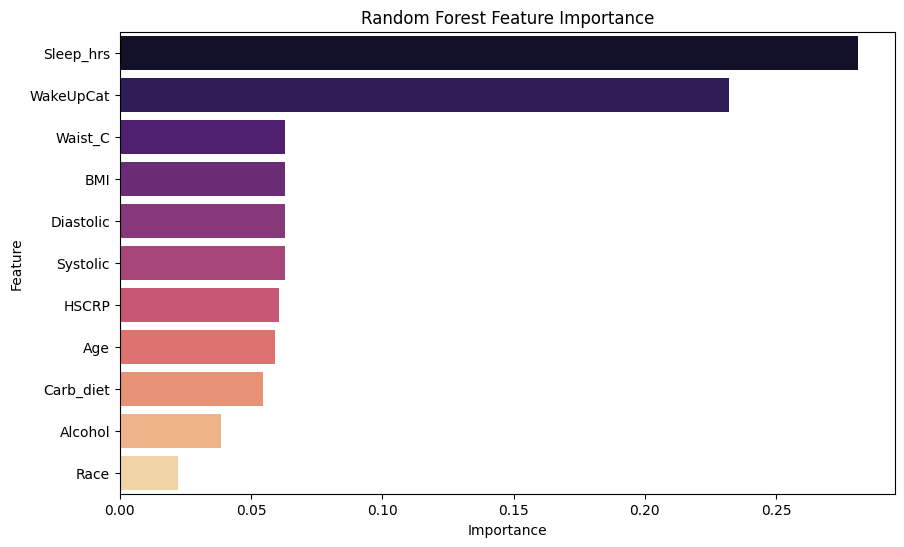

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Random Forest Feature Importance')
plt.show()

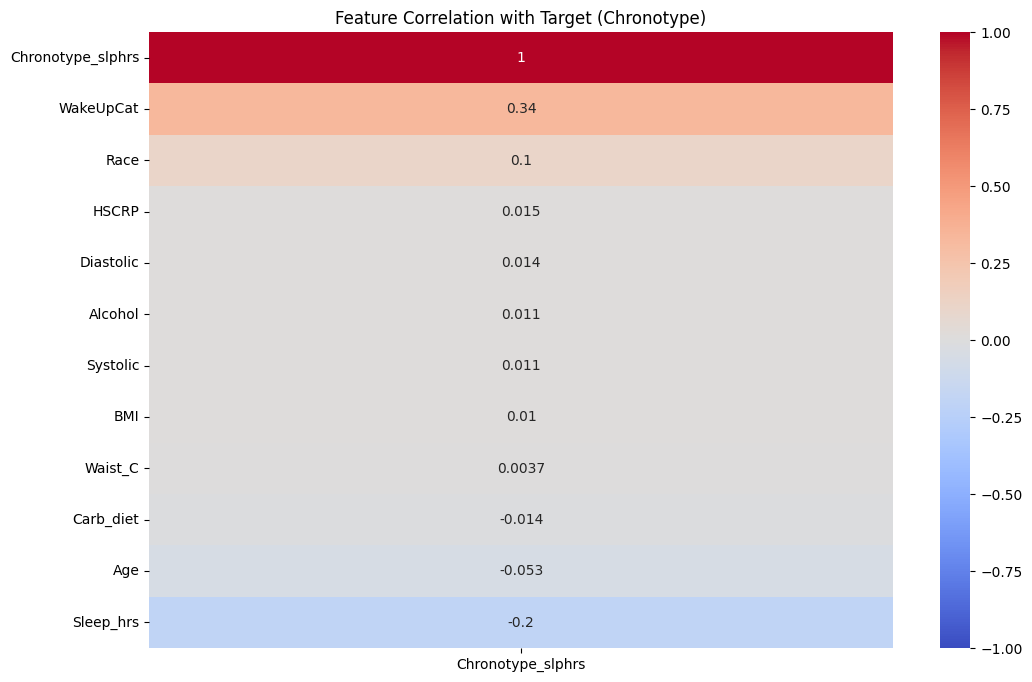

Potential Noisy Features (Importance < 2%):


,Feature,Importance


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = X.join(y).corr()
sns.heatmap(correlation_matrix[['Chronotype_slphrs']].sort_values(by='Chronotype_slphrs', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Target (Chronotype)')
plt.show()

# 2. Identify features with near-zero importance
low_importance_threshold = 0.02
noisy_candidates = feature_importance_df[feature_importance_df['Importance'] < low_importance_threshold]
print("Potential Noisy Features (Importance < 2%):")
display(noisy_candidates)

### Outlier Detection
We will use box plots to identify extreme values in our numerical features. In biological data, some 'outliers' are valid clinical variations, but extreme ones can negatively affect model convergence and accuracy.

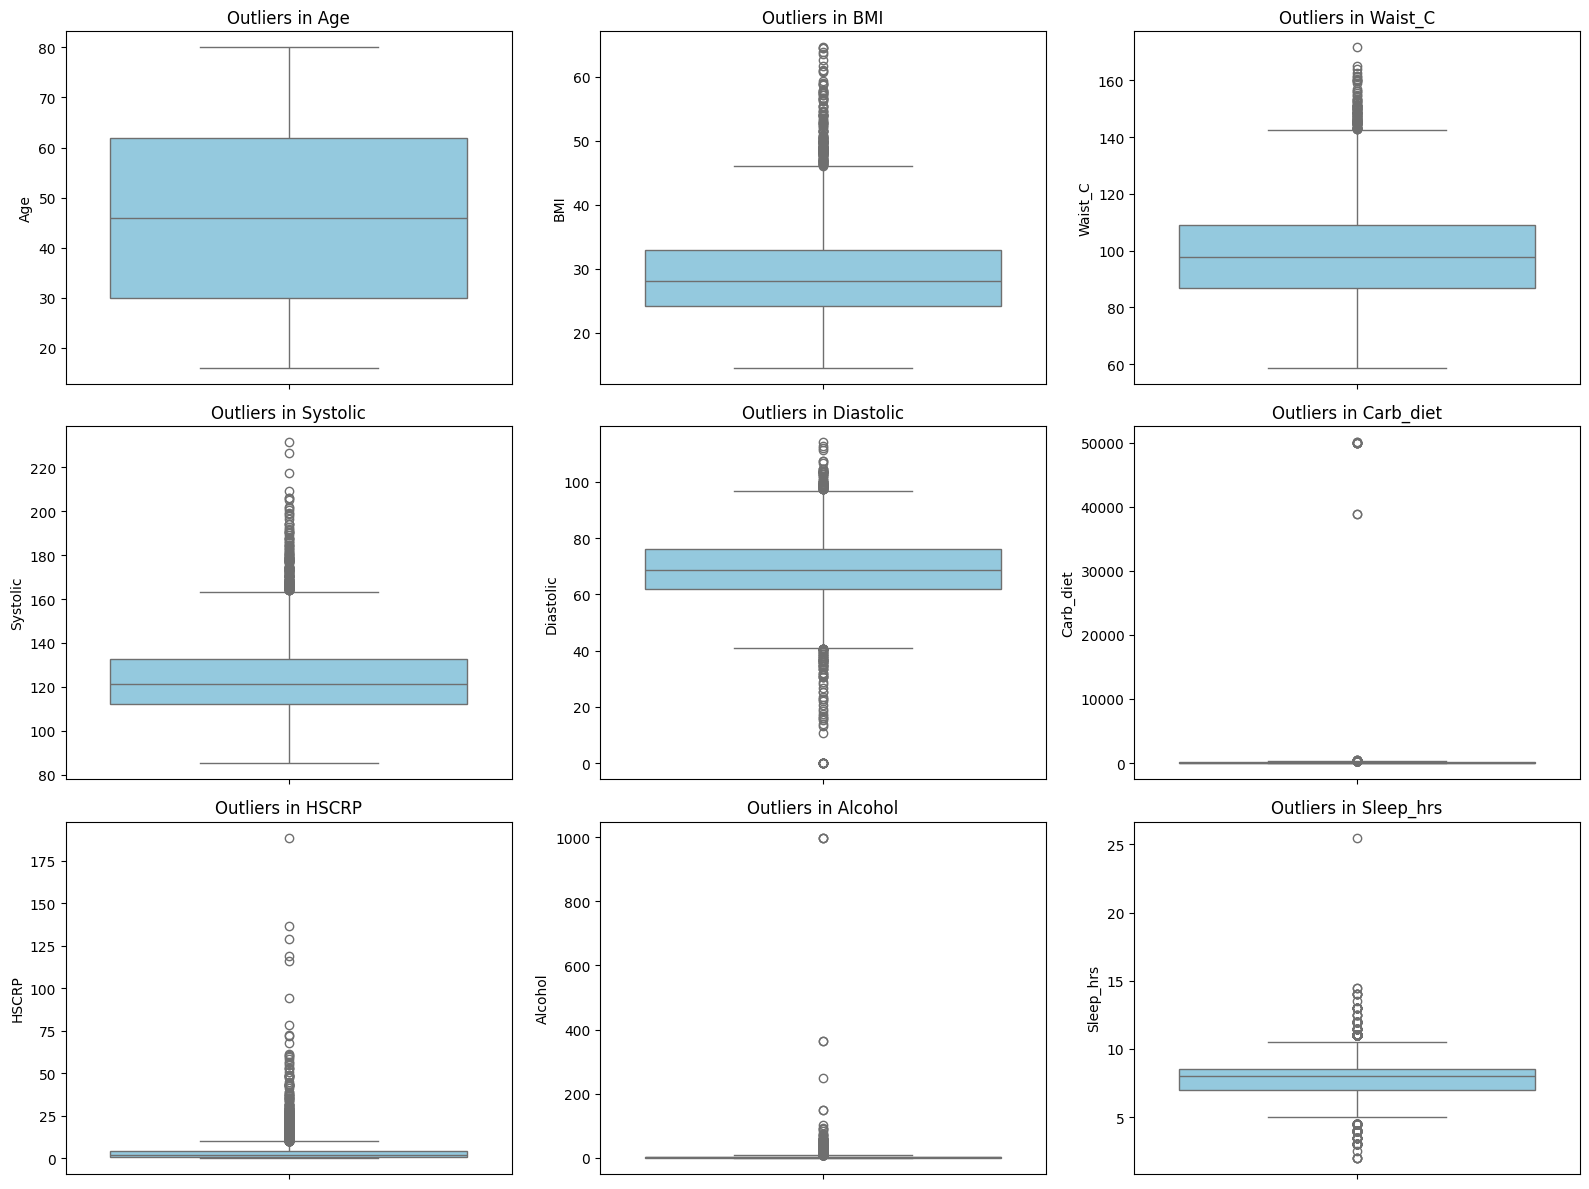

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier inspection
num_cols = ['Age', 'BMI', 'Waist_C', 'Systolic', 'Diastolic', 'Carb_diet', 'HSCRP', 'Alcohol', 'Sleep_hrs']

plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

Based on the plots above, we can identify which features have the most significant outliers (e.g., `HSCRP` or `Alcohol` often have long tails). We can then decide whether to clip these values to a certain percentile or remove the extreme rows.

### Observation on Noisy Features
Features like `Gender` and `Smokingstatus` show extremely low correlation and importance. In biological data, these can sometimes act as noise, especially if their distribution is heavily skewed or unrelated to the circadian rhythm metrics we are predicting.

Would you like to try retraining the models without these low-importance features to see if it reduces overfitting?

### Model Ensembling: Stacking
Stacking uses a 'meta-model' to learn how to best combine the predictions of your top-performing models (RF, XGB, and NN).

In [37]:
# Retrain Stacking Ensemble on Outlier-Clipped Data
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Using existing rf_model configuration
rf_robust = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5, class_weight='balanced', random_state=42)

estimators = [
    ('rf', rf_robust),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'))
]

stack_model_robust = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_model_robust.fit(X_train, y_train_encoded)
y_pred_robust = stack_model_robust.predict(X_test)

print("Stacking Ensemble Accuracy (Outliers Clipped):", accuracy_score(y_test_encoded, y_pred_robust))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_robust, target_names=le.classes_.astype(str)))


Stacking Ensemble Accuracy (Outliers Clipped): 0.7441860465116279

Classification Report:
              precision    recall  f1-score   support

         1.0       0.66      0.49      0.56       156
         2.0       0.71      0.73      0.72       344
         3.0       0.79      0.87      0.83       443
         4.0       0.72      0.69      0.70        74
         5.0       0.74      0.65      0.69       101

    accuracy                           0.74      1118
   macro avg       0.72      0.69      0.70      1118
weighted avg       0.74      0.74      0.74      1118

